In [1]:
!pip3 install pandas

You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [31]:
df = pd.read_csv('eng_tag_r.csv')
print(df)

   target (eng)  eng_in  eng_on  eng_at  eng_by  cym_yn  cym_ar  cym_NULL  \
0            in       1       0       0       0       1       0         0   
1            in       1       0       0       0       1       0         0   
2            in       1       0       0       0       1       0         0   
3            on       0       1       0       0       0       1         0   
4            in       1       0       0       0       1       0         0   
5            in       1       0       0       0       1       0         0   
6            on       0       1       0       0       0       1         0   
7            in       1       0       0       0       0       0         1   
8            in       1       0       0       0       0       0         0   
9            on       0       1       0       0       0       1         0   
10           in       1       0       0       0       1       0         0   
11           at       0       0       1       0       1       0         0   

In [32]:
df.head()

,target (eng),eng_in,eng_on,eng_at,eng_by,cym_yn,cym_ar,cym_NULL,cym_mewn,cym_wrth,...,pol_przy,tur_-inda,tur_-da,yor_ninu,yor_li,yor_ni,yor_lori,yor_lẹhin,yor_sinu,yor_leti
0,in,1,0,0,0,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
1,in,1,0,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,in,1,0,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
3,on,0,1,0,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4,in,1,0,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0


In [33]:
features = ['eng_in','eng_on','eng_at','cym_yn','cym_ar','cym_NULL','cym_mewn','cym_wrth','deu_in','deu_auf','deu_zur','deu_vor','deu_an','fin_-ssa','fin_-lla','fin_-lle','fin_NULL','hat_nan','hat_sou','hat_NULL','hat_bò_la','hau_cikin','hau_a','hau_kan','hau_ciki','hau_NULL','hin_mẽ','hin_par','hin_NULL','hin_ke','hin_pas','hin_kinare','jav_ing','jav_sacedhaké','jav_sacedhaking','jav_pinggir','jav_sajroning','jav_sakiwa','jav_tengené','pol_w','pol_na','pol_z','pol_u','pol_przy','tur_-inda','tur_-da','yor_ninu','yor_li','yor_ni','yor_lori','yor_lẹhin','yor_sinu','yor_leti']
x = df.loc[:, features].values

In [34]:
y = df.loc[:,['target (eng)']].values

In [35]:
x = StandardScaler().fit_transform(x)

In [36]:
pd.DataFrame(data = x, columns = features).head()

,eng_in,eng_on,eng_at,cym_yn,cym_ar,cym_NULL,cym_mewn,cym_wrth,deu_in,deu_auf,...,pol_przy,tur_-inda,tur_-da,yor_ninu,yor_li,yor_ni,yor_lori,yor_lẹhin,yor_sinu,yor_leti
0,0.731925,-0.550482,-0.362738,0.932505,-0.586302,-0.154303,-0.320256,-0.154303,1.123903,-0.658281,...,0.0,1.816590,-1.123903,2.483277,-0.440959,-0.731925,-0.362738,-0.154303,-0.154303,0.0
1,0.731925,-0.550482,-0.362738,0.932505,-0.586302,-0.154303,-0.320256,-0.154303,-0.889757,1.519109,...,0.0,-0.550482,0.889757,-0.402694,2.267787,-0.731925,-0.362738,-0.154303,-0.154303,0.0
2,0.731925,-0.550482,-0.362738,0.932505,-0.586302,-0.154303,-0.320256,-0.154303,1.123903,-0.658281,...,0.0,-0.550482,0.889757,-0.402694,-0.440959,1.366260,-0.362738,-0.154303,-0.154303,0.0
3,-1.366260,1.816590,-0.362738,-1.072381,1.705606,-0.154303,-0.320256,-0.154303,-0.889757,-0.658281,...,0.0,1.816590,-1.123903,-0.402694,2.267787,-0.731925,-0.362738,-0.154303,-0.154303,0.0
4,0.731925,-0.550482,-0.362738,0.932505,-0.586302,-0.154303,-0.320256,-0.154303,1.123903,-0.658281,...,0.0,-0.550482,0.889757,-0.402694,-0.440959,1.366260,-0.362738,-0.154303,-0.154303,0.0


In [37]:
pca = PCA(n_components=2)

In [38]:
principalComponents = pca.fit_transform(x)

In [39]:
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

In [40]:
principalDf.head(5)

,principal component 1,principal component 2
0,-2.997059,-1.309582
1,-0.004038,0.514159
2,-2.966359,-0.263405
3,5.344803,-3.400789
4,-2.463931,0.059892


In [41]:
df[['target (eng)']].head()

,target (eng)
0,in
1,in
2,in
3,on
4,in


In [42]:
finalDf = pd.concat([principalDf, df[['target (eng)']]], axis = 1)
finalDf.head(5)

,principal component 1,principal component 2,target (eng)
0,-2.997059,-1.309582,in
1,-0.004038,0.514159,in
2,-2.966359,-0.263405,in
3,5.344803,-3.400789,on
4,-2.463931,0.059892,in


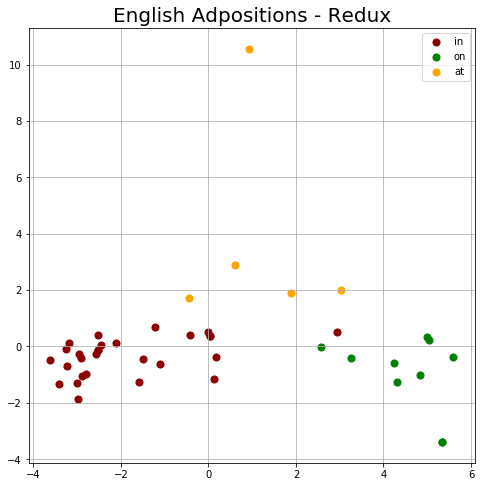

In [43]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_title('English Adpositions - Redux', fontsize = 20)


targets = ['in','on','at']
colors = ['darkred', 'green', 'orange']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target (eng)'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [17]:
pca.explained_variance_ratio_

array([0.1970571 , 0.08700474])